<a href="https://colab.research.google.com/github/Ryan56-56/porject2ML/blob/main/project2test(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [8]:
BATCH_SIZE = 128

def get_dataloaders(batch_size=BATCH_SIZE):
    mean = (0.4914, 0.4822, 0.4465)
    std = (0.2470, 0.2435, 0.2616)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
    test_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader

train_loader, val_loader = get_dataloaders()



100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [9]:
NUM_CLASSES = 10

class ResNet50CIFAR10(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)

model = ResNet50CIFAR10().to(DEVICE)
model



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


ResNet50CIFAR10(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

In [10]:
def freeze_backbone(model, freeze=True):
    for param in model.backbone.parameters():
        param.requires_grad = not freeze

def create_optimizer(model, lr):
    return optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

def create_scheduler(optimizer):
    return optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)



In [11]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    preds_all, targets_all = [], []

    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds_all.append(outputs.argmax(1).cpu().numpy())
        targets_all.append(targets.cpu().numpy())

    preds_all = np.concatenate(preds_all)
    targets_all = np.concatenate(targets_all)

    return running_loss / len(loader.dataset), f1_score(targets_all, preds_all, average="macro")


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    preds_all, targets_all = [], []

    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * images.size(0)
            preds_all.append(outputs.argmax(1).cpu().numpy())
            targets_all.append(targets.cpu().numpy())

    preds_all = np.concatenate(preds_all)
    targets_all = np.concatenate(targets_all)

    return running_loss / len(loader.dataset), f1_score(targets_all, preds_all, average="macro")



In [12]:
EPOCHS = 50
FREEZE_EPOCHS = 10

criterion = nn.CrossEntropyLoss()

# Freeze backbone initially
freeze_backbone(model, freeze=True)
optimizer = create_optimizer(model, lr=1e-3)
scheduler = create_scheduler(optimizer)

backbone_unfrozen = False

for epoch in range(EPOCHS):

    # Unfreeze at epoch 10
    if epoch == FREEZE_EPOCHS and not backbone_unfrozen:
        print(f"\n[Epoch {epoch}] Unfreezing backbone...")
        freeze_backbone(model, freeze=False)
        optimizer = create_optimizer(model, lr=1e-4)
        scheduler = create_scheduler(optimizer)
        backbone_unfrozen = True

        # Debug check
        for name, p in model.named_parameters():
            if "backbone" in name:
                print(name, "requires_grad =", p.requires_grad)

    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_f1 = evaluate(model, val_loader, criterion)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}"
    )



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/50] Train Loss: 1.8632 | Train F1: 0.3581 | Val Loss: 1.6287 | Val F1: 0.4442


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [2/50] Train Loss: 1.7269 | Train F1: 0.3967 | Val Loss: 1.5738 | Val F1: 0.4549


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

Epoch [48/50] Train Loss: 0.0373 | Train F1: 0.9875 | Val Loss: 0.4728 | Val F1: 0.8963


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [49/50] Train Loss: 0.0360 | Train F1: 0.9881 | Val Loss: 0.4752 | Val F1: 0.8969


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [50/50] Train Loss: 0.0359 | Train F1: 0.9884 | Val Loss: 0.4682 | Val F1: 0.8978


In [13]:
torch.save(model.state_dict(), "resnet50_cifar10.pth")
print("Model saved.")



Model saved.


In [15]:
print("Final evaluation on full test set:")
final_f1 = evaluate(model, val_loader, criterion)
print("Final F1:", final_f1)

Final evaluation on full test set:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Final F1: (0.4682465843200684, 0.8978158522648109)


In [16]:
# Load model weights (optional if model is already in memory)
model.load_state_dict(torch.load("resnet50_cifar10.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

val_loss, val_f1 = evaluate(model, val_loader, criterion)

print("=== Final Evaluation on Test Set ===")
print(f"Val Loss: {val_loss:.4f}")
print(f"Val F1 Score: {val_f1:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


=== Final Evaluation on Test Set ===
Val Loss: 0.4682
Val F1 Score: 0.8978


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


=== Confusion Matrix (Raw Values) ===
[[915  10  20   3   7   3   5   4  20  13]
 [  8 950   0   0   1   2   4   1   3  31]
 [ 17   0 887  19  37  11  20   8   1   0]
 [  5   0  21 785  29 110  27  14   5   4]
 [  3   0  25  22 893  16  15  23   2   1]
 [  5   2  10 102  20 829  13  15   1   3]
 [  4   0  12  24   9   5 943   1   0   2]
 [ 13   2  11  16  25  34   3 892   0   4]
 [ 23   6   3   6   0   0   0   0 954   8]
 [ 10  38   0   5   1   0   0   0  15 931]]


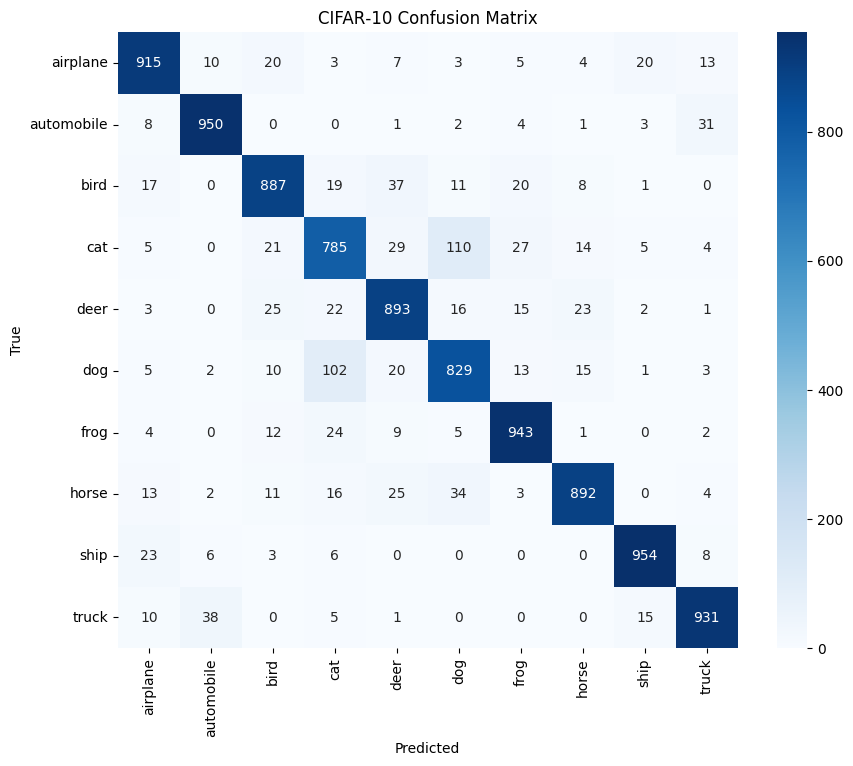

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# CIFAR‑10 class names
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Ensure model is in eval mode
model.load_state_dict(torch.load("resnet50_cifar10.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        outputs = model(images)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_targets, all_preds)

print("=== Confusion Matrix (Raw Values) ===")
print(cm)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CIFAR‑10 Confusion Matrix")
plt.show()
